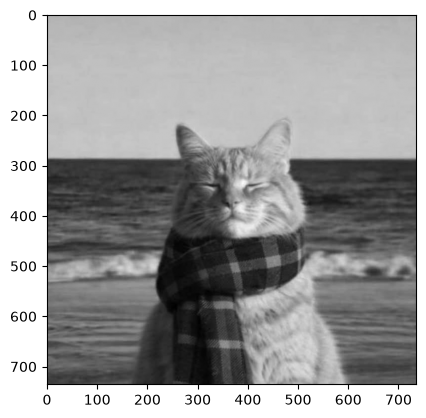

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

image = cv2.imread('img1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray,cmap = "gray")
plt.show()

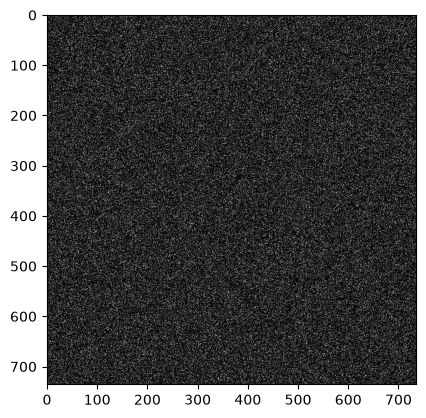

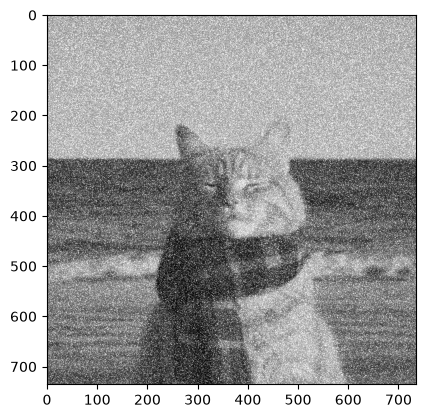

In [3]:
mean = 0
stddev = 100
noize_gauss =  np.zeros(image_gray.shape,np.uint8)
cv2.randn(noize_gauss, mean,stddev)
plt.imshow(noize_gauss, cmap ="gray")
plt.show()

image_ng = cv2.add(image_gray, noize_gauss)
plt.imshow(image_ng,cmap ="gray")
plt.show()

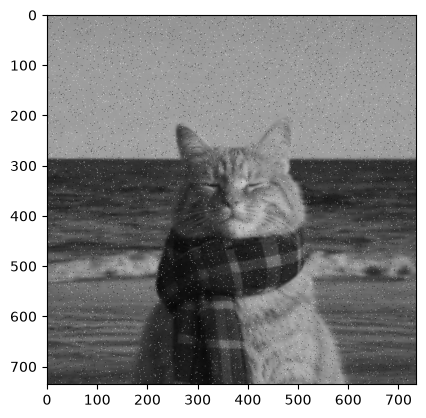

In [4]:
noise = np.random.randint(0,101,size = (image_gray.shape[0], image_gray.shape[1]),dtype = int)
zero_p = np.where(noise  == 0)
one_p = np.where(noise ==100)

image_sp = copy.deepcopy(image_gray)
image_sp[zero_p] = 0
image_sp[one_p] = 255
plt.imshow(image_sp, cmap = "gray")
plt.show()

Salt and Pepper + Median k = 3: MSE =  0.6803096201559546  SSIM =  0.9946623098587467


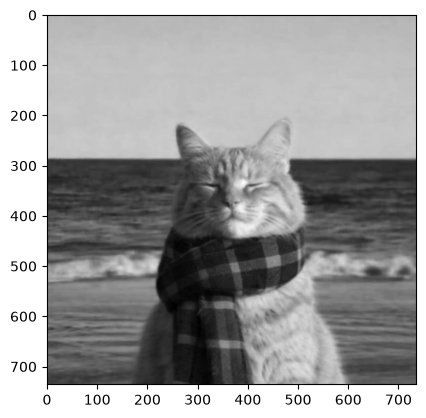

In [5]:
image_sp_m = cv2.medianBlur(image_sp,3)
mse_sp_m = mean_squared_error(image_gray,image_sp_m)
(ssim_sp_m, diff) = structural_similarity(image_gray,image_sp_m,full = True)
print("Salt and Pepper + Median k = 3: MSE = ",mse_sp_m," SSIM = ", ssim_sp_m)
plt.imshow(image_sp_m, cmap="gray")
plt.show()

Salt and pepper + Gausse k = 3: MSE =  30.635083146266542  SSIM =  0.808621384268654


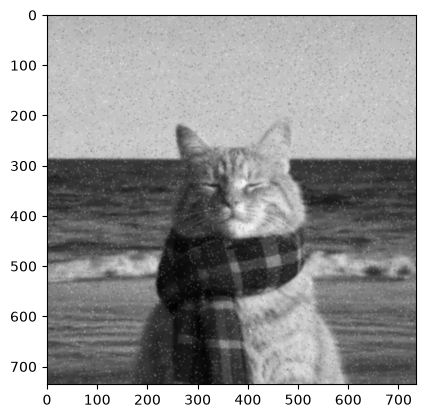

In [6]:
image_sp_g = cv2.GaussianBlur(image_sp, (5,5), 0)
mse_sp_g = mean_squared_error(image_gray, image_sp_g)
(ssim_sp_g, diff) = structural_similarity(image_gray,image_sp_g,full = True)
print("Salt and pepper + Gausse k = 3: MSE = ",mse_sp_g," SSIM = ", ssim_sp_g)
plt.imshow(image_sp_g, cmap="gray")
plt.show()

Salt and Pepper + Bilateral:  MSE = 61.15599339851134  SSIM = 0.8114361176064335


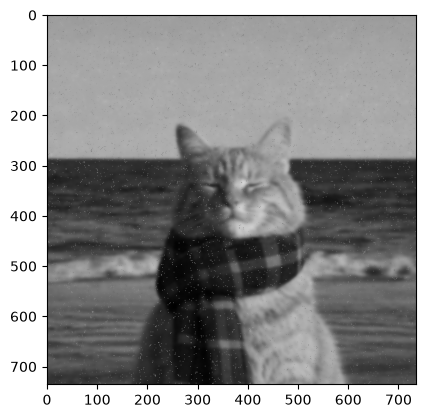

In [7]:
image_sp_b = cv2.bilateralFilter(image_sp, 9, 75, 75)
mse_sp_b = mean_squared_error(image_gray, image_sp_b)
(ssim_sp_b, diff) = structural_similarity(image_gray, image_sp_b, full=True)
print("Salt and Pepper + Bilateral:  MSE =", mse_sp_b, " SSIM =", ssim_sp_b)
plt.imshow(image_sp_b, cmap="gray")
plt.show()

Gauss + Median k=3: MSE =  829.3252820770322  SSIM =  0.20668959715723664


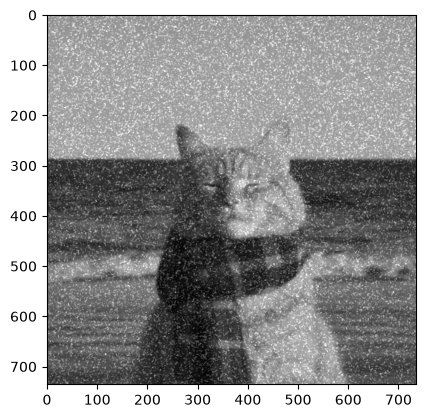

In [8]:
image_ng_m = cv2.medianBlur(image_ng,3)
mse_ng_m = mean_squared_error(image_gray,image_ng_m)
(ssim_ng_m, diff) = structural_similarity(image_gray,image_ng_m, full = True)
print("Gauss + Median k=3: MSE = ", mse_ng_m, " SSIM = ", ssim_ng_m)
plt.imshow(image_ng_m, cmap="gray")
plt.show()

Gauss + GAuss k = 3: MSE =  1417.7123829601844  SSIM =  0.38913712338335027


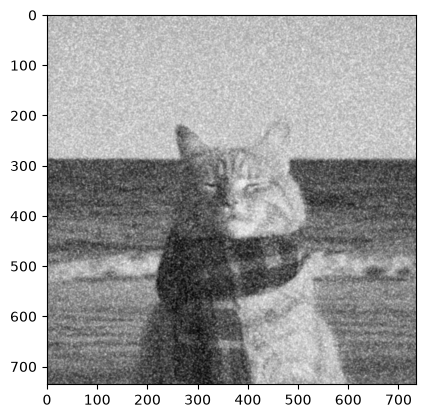

In [9]:
image_ng_g = cv2.GaussianBlur(image_ng, (5,5), 0)
mse_ng_g = mean_squared_error(image_gray, image_ng_g)
(ssim_ng_g, diff) = structural_similarity(image_gray,image_ng_g,full = True)
print("Gauss + GAuss k = 3: MSE = ",mse_ng_g," SSIM = ", ssim_ng_g)
plt.imshow(image_ng_g, cmap="gray")
plt.show()

Gausse + Bilateral:  MSE = 1374.8195814626654  SSIM = 0.26006191094089653


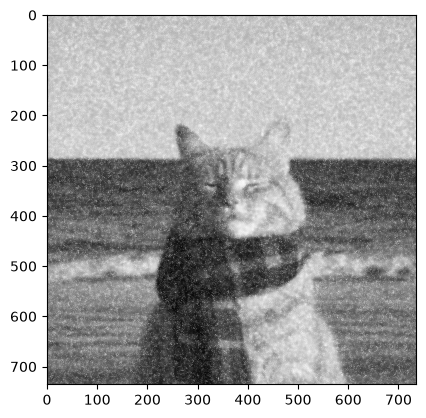

In [10]:
image_ng_b = cv2.bilateralFilter(image_ng, 9, 75, 75)
mse_ng_b = mean_squared_error(image_gray, image_ng_b)
(ssim_ng_b, diff) = structural_similarity(image_gray, image_ng_b, full=True)
print("Gausse + Bilateral:  MSE =", mse_ng_b, " SSIM =", ssim_ng_b)
plt.imshow(image_ng_b, cmap="gray")
plt.show()

Gausse + Bilateral:  MSE = 1154.671712547259  SSIM = 0.656465589697936


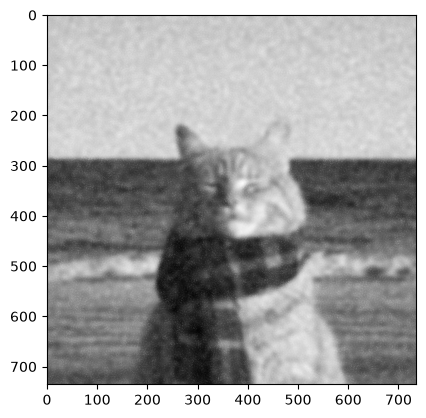

In [11]:
image_ng_b = cv2.bilateralFilter(image_ng, 15, 150, 150)
mse_ng_b = mean_squared_error(image_gray, image_ng_b)
(ssim_ng_b, diff) = structural_similarity(image_gray, image_ng_b, full=True)
print("Gausse + Bilateral:  MSE =", mse_ng_b, " SSIM =", ssim_ng_b)
plt.imshow(image_ng_b, cmap="gray")
plt.show()

Gauss + NLM h = 20:  MSE = 3308.6213337370036  SSIM = 0.05787624290520945


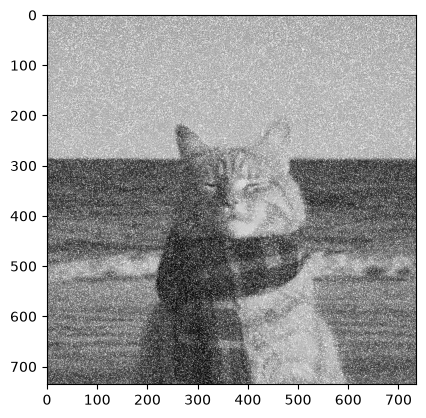

In [12]:
image_ng_nlm = cv2.fastNlMeansDenoising(image_ng, h=20)
mse_ng_nlm = mean_squared_error(image_gray, image_ng_nlm)
(ssim_ng_nlm, diff) = structural_similarity(image_gray, image_ng_nlm, full=True)
print("Gauss + NLM h = 20:  MSE =", mse_ng_nlm, " SSIM =", ssim_ng_nlm)
plt.imshow(image_ng_nlm, cmap="gray")
plt.show()

Gauss + NLM h = 100:  MSE = 1299.6933519907845  SSIM = 0.7804200050964685


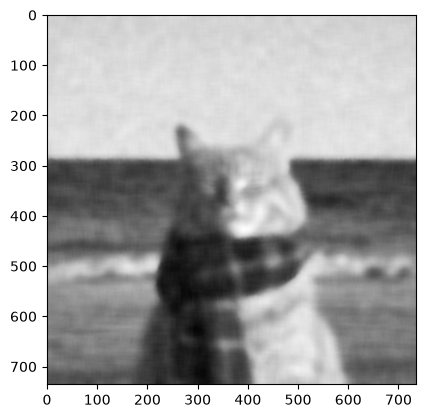

In [13]:
image_ng_nlm = cv2.fastNlMeansDenoising(image_ng, h=100)
mse_ng_nlm = mean_squared_error(image_gray, image_ng_nlm)
(ssim_ng_nlm, diff) = structural_similarity(image_gray, image_ng_nlm, full=True)
print("Gauss + NLM h = 100:  MSE =", mse_ng_nlm, " SSIM =", ssim_ng_nlm)
plt.imshow(image_ng_nlm, cmap="gray")
plt.show()

Gauss + NLM h = 30:  MSE = 1886.541488214792  SSIM = 0.3770877856791207


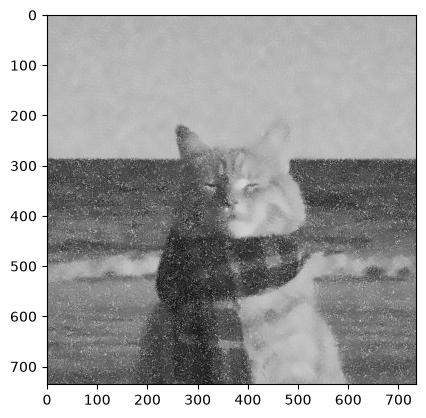

In [14]:
image_ng_nlm = cv2.fastNlMeansDenoising(image_ng, h=30)
mse_ng_nlm = mean_squared_error(image_gray, image_ng_nlm)
(ssim_ng_nlm, diff) = structural_similarity(image_gray, image_ng_nlm, full=True)
print("Gauss + NLM h = 30:  MSE =", mse_ng_nlm, " SSIM =", ssim_ng_nlm)
plt.imshow(image_ng_nlm, cmap="gray")
plt.show()

In [16]:
print("Для шума Гаусса лучшие NLM и Bilateral. NLM лучше по SSIM, но размывает, Bilateral чуть хуже по SSIM, но сохраняет резкость")

Для шума Гаусса лучшие NLM и Bilateral. NLM лучше по SSIM, но размывает, Bilateral чуть хуже по SSIM, но сохраняет резкость


In [17]:
print("Для salt and pepper лучше Median, он полностью убрал шум")

Для salt and pepper лучше Median, он полностью убрал шум
